# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 3. Логистическая регрессия.


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание**

* Задача 1 &mdash; 30 баллов;
* Задача 2 &mdash; 20 баллов;
* Задача 3 &mdash; 20 баллов;
* Задача 4 &mdash; 30 баллов;
* Задача 5 &mdash; 90 баллов.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from time import time
from sklearn.base import BaseEstimator
from typing import Literal
from time import time

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier

import scipy.stats as sps

from typing import Callable, Any, Tuple, List, Union, Optional

sns.set(style="whitegrid", palette="Set2")

In [679]:
# Bot check

# HW_ID: fpmi_ad3
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

Задача 2: Исследование логистической регрессии на данных с бинарными признаками.
▫️ В выводе ничего не сказано про несмещенность оценок вероятностей. Комм. 🟢 В этом была исходная цель задачи. (-3.0)

Задача 3: Многоклассовая логистическая регрессия.
▫️ Ошибка в размерностях матриц. Комм. 🟢 . Инд. комм. Ошибка в размерностях при записи градиента в матричном виде. (-3.0)

Задача 4: Реализация логистической регрессии.
▫️ Некорректный выбор батча в SGD. Комм. 🟢 На каждой итерации он должен создаваться путем независимого выбора случайных объектов с повторением. В методе fit для SGD используется выбор батчей без повторений (replace=False), тогда как стохастический градиентный спуск требует выбора с повторением (replace=True) на каждой итерации (см. ячейку с методом fit). (-2.0)

Задача 5: Исследование логистической регрессии.
▫️ Нет графика сравнения разных learning_rate. Инд. комм. Отсутствует итоговый график зависимости метрики Accuracy от learning_rate. (-5.0)
▫️ Нет численной аналитики для сравнения скоростей сходимости. Комм. Сделаны верные выводы, но они основаны только на кривых обучения. Следовало бы посчитать количество итераций / затраченное время на обучение на основе критерия остановки. Делать вывод ТОЛЬКО ЛИШЬ по кривым нельзя. (-4.0)

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 3**
1. [ссылка](https://chatgpt.com/share/69ab3c72-7128-8008-a1ff-644a4a6112d2)
    - оформление решения


*Привет!*

*Перед тобой увлекательная домашка по логистической регрессии и градиентным методам оптимизации. Надеемся, что тебе она понравится, ты точно найдешь в ней что-то интересное. В условии оставлены некоторые скрытые подсказки, будет хорошо, если ты сначала постараешься подумать самостоятельно, а затем раскроешь содержимое подсказки. Если у тебя будут вопросы по условию, можешь обратиться с ними в чат. Только очень желательно не делиться в чате фрагментами решения.*

*Успехов в решении!*

---
### Задача 1.

*Для начала посмотрим на простых примерах, как работает логистическая регрессия, и поймем некоторые ее важные свойства. Перед выполнением задачи ознакомтесь с ноутбуком по логистической регрессии с занятия.*

> Одно из интересных свойств модели логистической регрессии — *при соблюдении её предположений* она дает возможность получать **несмещенные оценки вероятностей** принадлежности объекта к определенному классу. Понимать это можно следующим образом. Рассмотрим объект $x$ и соответствующее предсказание вероятности $\widehat{p}(x)$ для класса 1. Если взять небольшую окрестность объекта $x$, то доля объектов с истинным классом 1 в этой окрестности будет приблизительно равна $\widehat{p}(x)$.  

Далее проверим это свойство на примере.

С помощью кода ниже сгенерируйте данные, состоящие из одного вещественного признака и бинарного таргета.

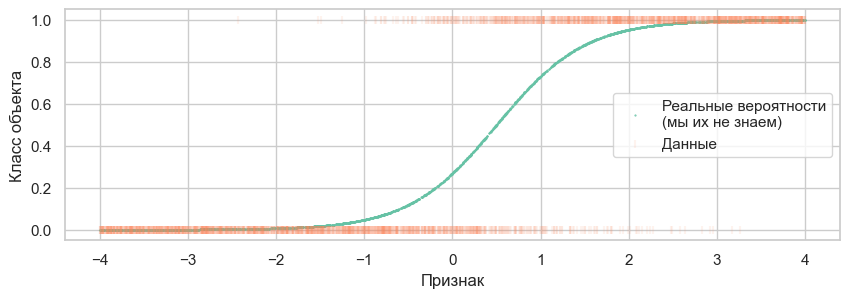

In [680]:
sample_size = 3_000  # Размер выборки

# Признаки
X_train = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(1 - 2 * X_train.ravel()))
y_train = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X_train, y_mean_true, marker=".", s=1, label="Реальные вероятности\n(мы их не знаем)")
plt.scatter(X_train, y_train, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

Обучите логистическую регрессию, используя реализацию из `sklearn`, при этом свободный коэффициент должен присутствовать в модели. Укажите также `penalty='none'`.

*Делить данные на обучающую и тестовую части в данном случае не нужно, поскольку цель данной задачи &mdash; посмотреть, как модель представляет исходные данные, а не оценить ее качество.*

In [681]:
model = LogisticRegression(penalty = None)
model.fit(X_train, y_train)

LogisticRegression(penalty=None)

Напечатайте оценку коэффициентов из обученной модели

In [682]:
print(f"intercept = {model.intercept_[0]:.4f},", f"coef = {model.coef_.ravel()[0]:.4}")

intercept = -0.9021, coef = 1.921


Вспомним, обученная модель представляет собой функцию $\widehat{p}: \mathbb{R} \to [0, 1]$, которая для каждого объекта $x \in \mathbb{R}$ возвращает для него оценку вероятности класса 1. Постройте график этой функции.

Ниже объявлена сетка значений  $x \in \mathbb{R}$ для построения графика. На этом же графике:
* постройте предсказания вероятностей класса 1 (бинаризация оценок вероятностей),
* отобразите обучающую выборку.

Похожий график есть в ноутбуке с занятия.

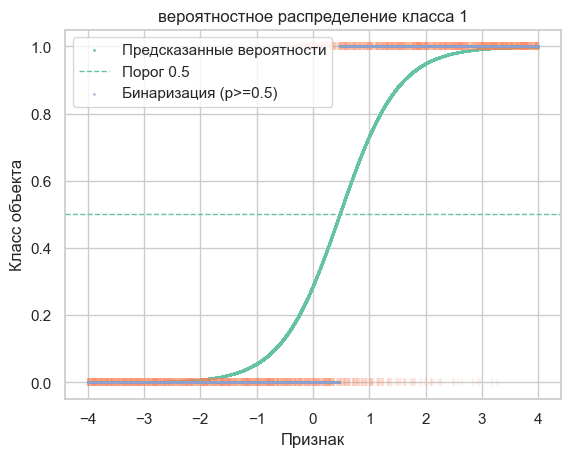

In [683]:
X_grid = np.linspace(-4, 4, 10_000).reshape((-1, 1))
y_pred_proba = model.predict_proba(X_grid) # предсказание

plt.figure()
plt.scatter(X_grid, y_pred_proba[:, 1], s = 1, label="Предсказанные вероятности")
plt.scatter(X_train, y_train, marker='|', alpha=0.1)

#бинаризация
plt.axhline(0.5, linestyle="--", linewidth=1, label="Порог 0.5")
y_pred_bin = (y_pred_proba[:, 1] >= 0.5).astype(int)
plt.scatter(X_grid.ravel(), y_pred_bin, s=1, alpha=0.6, label="Бинаризация (p>=0.5)")

plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.title("вероятностное распределение класса 1")
plt.legend();

Разбейте отрезок $[-4, 4]$ на одинаковые бины длины длины 0.2 и для каждого бина посчитайте долю класса 1 среди объектов обучающей выборки, попавших в данный бин. Полученные значения добавьте на график предсказаний вероятностей и сравните эти графики. Проинтерпретируйте полученные результаты.


<details>
<summary> ➡️ Кликни для показа подсказки </summary>
Может помочь <code>np.digitize</code> и метод <code>groupby</code> для таблиц <code>pandas</code>. Рекомендуем посмотреть <a href="https://thetahat.ru/courses/python">обучающие ноутбуки</a> по библиотекам.
</details>

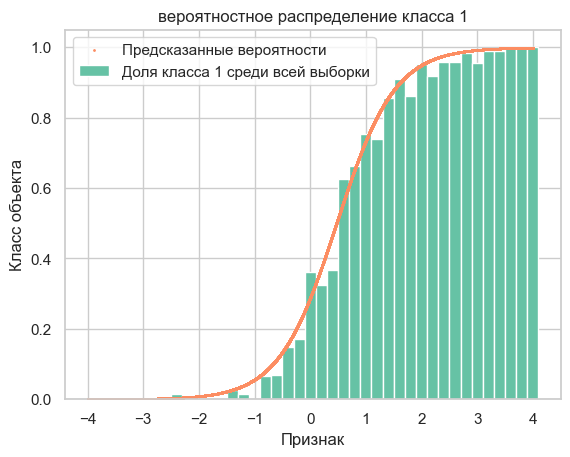

In [684]:
# разбиваем на интервалы
bins = np.linspace(-4, 4, 41)
intervals = pd.Series(np.digitize(X_train, bins, right=False).reshape(-1))  # номер бина для каждого объекта

df = pd.DataFrame({"y": y_train.ravel(), "interval": intervals})
df_bin = df.groupby("interval", as_index=False).mean()  # среднее y в бине = доля класса 1 в этом бине

df_bin["val"] = -4 + df_bin["interval"] * 0.2 # координата бина по X (левый край)

plt.bar(df_bin["val"], df_bin["y"], width=0.2, label = "Доля класса 1 среди всей выборки")
plt.scatter(X_grid, y_pred_proba[:, 1], s = 1, label = "Предсказанные вероятности")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.title("вероятностное распределение класса 1")
plt.legend();


Повторите проведенное исследование для следующих данных и сравните результаты.

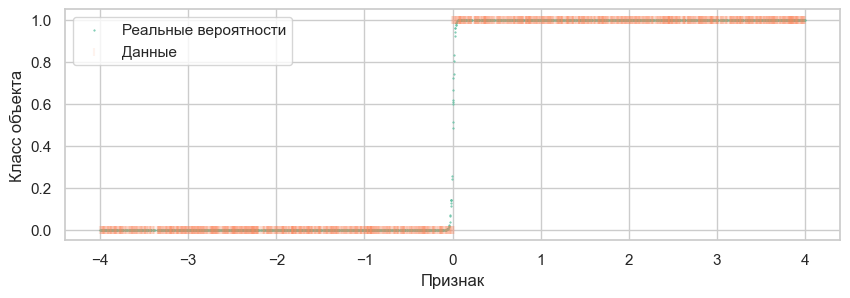

In [685]:
# Признаки
X_train = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(-100 * X_train.ravel()))
y_train = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X_train, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X_train, y_train, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

In [686]:
model = LogisticRegression(penalty = None)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_grid)

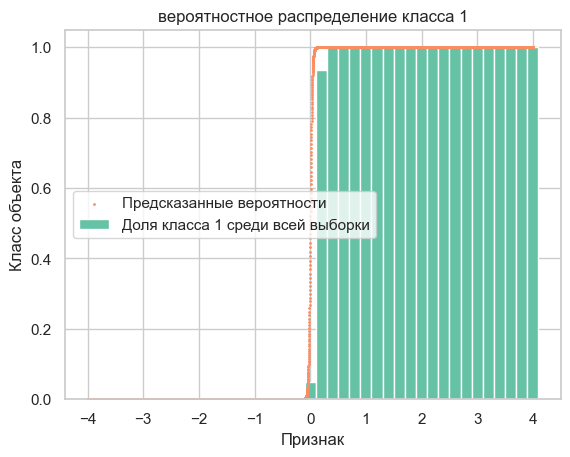

In [687]:
# разбиваем на интервалы
bins = np.linspace(-4, 4, 41)
intervals = pd.Series(np.digitize(X_train, bins, right=False).reshape(-1))  # номер бина для каждого объекта

df = pd.DataFrame({"y": y_train.ravel(), "interval": intervals})
df_bin = df.groupby("interval", as_index=False).mean()  # среднее y в бине = доля класса 1 в этом бине

df_bin["val"] = -4 + df_bin["interval"] * 0.2 # координата бина по X (левый край)

plt.bar(df_bin["val"], df_bin["y"], width=0.2, label = "Доля класса 1 среди всей выборки")
plt.scatter(X_grid, y_pred_proba[:, 1], s = 1, label = "Предсказанные вероятности")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.title("вероятностное распределение класса 1")
plt.legend();

**Выводы:**


---
### Задача 2.

Продолжим исследовать модель логистической регрессии. Сгенерируем данные, состоящие из двух бинарных признаков и бинарного таргета

In [688]:
probs = np.random.uniform(size=8)
probs /= probs.sum()
probs

x = np.random.choice(np.arange(8), p=probs, size=10_000)
data = pd.DataFrame(
    np.unpackbits(np.array(x.reshape(-1, 1), dtype=">i8").view(np.uint8), axis=1)[:, -3:],
    columns=["feature_1", "feature_2", "target"],
)
data

,feature_1,feature_2,target
0,1,0,1
1,0,1,0
2,1,0,1
3,1,1,0
4,1,1,0
...,...,...,...
9995,1,1,0
9996,0,0,0
9997,0,0,1
9998,0,1,0


Особенность таких данных &mdash; конечное число *возможных различных* объектов. В данном случае их всего 4, по количеству всех возможных комбинаций значений признака. Соответственно, любой моделью мы можем сделать только 4 *различных* предсказания вероятности класса 1. Исследуем, как с этим справляется логистическая регрессия.

Сначала для сравнения посчитайте долю класса 1 для каждой категории объектов.

<details>
<summary> ➡️ Кликни для показа подсказки </summary>
    Используйте <code>pd.pivot_table</code>. Рекомендуем посмотреть <a href="https://thetahat.ru/courses/python">обучающие ноутбуки</a> по библиотекам.
</details>

In [689]:
features = ["feature_1", "feature_2"]

df = pd.pivot_table(data, values = "target", index = features, aggfunc="mean")
df

target
feature_1 feature_2          
0         0          0.831071
          1          0.639167
1         0          0.474032
          1          0.213631

Обучите логистическую регрессию с `penalty='none'` и получите предсказания вероятностей для этих четырех типов объектов. Представьте результаты в таком виде, чтобы их удобно было сравнивать с частотами, посчитанными ранее.

In [690]:
# обучаем
model = LogisticRegression(penalty= None)
model.fit(data[features], data["target"])

y_pred_proba = model.predict_proba(data[features])[: , 1] # предсказание

data["target_pred"] = y_pred_proba
df_pred = pd.pivot_table(data, values = ["target_pred", "target"], index = features, aggfunc="mean")
df_pred


target  target_pred
feature_1 feature_2                       
0         0          0.831071     0.839592
          1          0.639167     0.624853
1         0          0.474032     0.469802
          1          0.213631     0.219954

Почему результаты существенно отличаются?

Для ответа на этот вопрос распишите формулу, которая задает модель логистической регрессии, указав все параметры. Какое предположение о данных при этом делает логистическая регрессия?

Заметим, что у нас всего 4 возможных "типа" объекта: $00$, $01$, $10$, $11$. При этом в логистической регрессии без взаимодействия всего 3 параметра, и модель имеет вид $P(Y=1 \mid x)=\sigma(\beta_0+\beta_1 x_1+\beta_2 x_2)$. Тем самым предполагается аддитивность вкладов признаков: эффект $x_1$ не зависит от $x_2$ (и наоборот), то есть взаимодействие признаков не учитывается, хотя в общем случае оно может быть важным.

Предложите и реализуйте способ модификации данных так, чтобы логистическая регрессия точнее предсказывала частоты, посчитанные ранее.

<details>
<summary> ➡️ Кликни для показа подсказки </summary>
Подумайте, какое преобразование признаков можно было бы сделать.
</details>

Опишите ваше предложение:

Чтобы учесть взаимосвязь признаков, можно добавить ещё один параметр через признак-взаимодействие: $x_3=x_1\cdot x_2$. Тогда итоговая модель будет выглядеть так: $P(Y=1 \mid x)=\sigma(\beta_0+\beta_1 x_1+\beta_2 x_2+\beta_3 x_3)$. Теперь для каждой комбинации $(x_1,x_2)$ значение логита может меняться более гибко, и модель лучше подстраивается под разные "типы" объектов.

Реализация:

In [691]:
data["feature_3"] = data["feature_1"] * data["feature_2"] # добавляем третий признак
features.append("feature_3")

model_2 = LogisticRegression(penalty= None)
model_2.fit(data[features], data["target"])

y_pred_proba_2 = model_2.predict_proba(data[features])[: , 1] # предсказание

data["target_pred_2"] = y_pred_proba_2
df_pred = pd.pivot_table(data, values = ["target_pred_2", "target_pred", "target"], index = features, aggfunc="mean")
df_pred


target  target_pred  target_pred_2
feature_1 feature_2 feature_3                                      
0         0         0          0.831071     0.839592       0.831148
          1         0          0.639167     0.624853       0.639217
1         0         0          0.474032     0.469802       0.474058
          1         1          0.213631     0.219954       0.213628

<font color="green" size="5"><b>Исправления ниже</b></font>

**Выводы:**

**Выводы:**

Видно, что после добавления третьего признака точность предсказания сильно возросла, а предсказанные вероятности стали гораздо ближе к эмпирическим частотам класса 1 для каждой категории объектов. Это показывает, что при корректно заданной модели логистическая регрессия дает несмещенные оценки вероятностей, а без учета взаимодействия признаков это свойство нарушается из-за неверной спецификации модели.

<font color="green" size="5"><b>Исправления выше</b></font>

---
### Задача 3.

*Не все в жизни ограничивается двумя классами, бывает и многоклассовый случай.*

Рассмотрим модель логистической регрессии для случая многоклассовой классификации. Пусть метка класса принимает значения в $K$-элементном множестве $\mathscr{Y} = \{1, ..., K\}$. Параметры модели $\theta$ являются матрицей размерности $K \times d$, где $d$ &mdash; количество признаков. 

Введем soft-max функцию: 
$$
\sigma(z) = \big( \sigma_1(z), \dots, \sigma_K(z) \big) = \left( \frac{e^{z_1}}{\sum_{i=1}^K e^{z_i}}, \dots, \frac{e^{z_K}}{\sum_{i=1}^K e^{z_i}} \right).
$$

Из определения ясно, что $\sum\limits_{k=1}^K \sigma_k(z) = 1$. Название функции связано с тем, что самая большая компонента вектора $z$ будет близка к $1$, а все остальные будут малы, но не равны нулю. Таким образом, происходит сглаженное взятие `argmax`.

По аналогии с простой логистической регрессией рассмотрим выборку объектов $x_1, ...,  x_n$, где $x_i = (x_{i1}, \dots, x_{id})^T \in \mathbb{R}^d$, и выборку таргетов $Y_1, ...,  Y_n \in \mathscr{Y}$
Модель логистической регрессии в многоклассовом случае предполагает, что $\mathsf{P}_{\theta}(Y_{i} = k) = \sigma_k(\theta x)$, где $\theta \in \mathbb{R}^{k \times d}$. Тогда обучение модели логистической регрессии в многоклассовом случае выглядит следующим образом:

$$
- \sum_{i=1}^n \sum_{k=1}^K I\{Y_i = k\} \log
    \sigma_k(\theta x_i)
\longrightarrow \min_{\theta}
$$


**1.** Определите множество моделей $\mathcal{M}$, соответствующее логистической регрессии.

$\mathcal{M}=\{\mu:\mathbb{R}^d\to[0,1]^K\ \mid\ \mu(x)=\sigma(\Theta x),\ \Theta\in\mathbb{R}^{K\times d}\}$

<font color="green" size="5"><b>Исправления ниже</b></font>

**2.** Выпишите формулы GD и SGD для максимизации этой функции правдоподобия. В формулу нужно упростить подобно тому, как было показано на занятии для бинарной классификации.

Пусть $Y_i^* = (y_{i1}, y_{i2}, \dots, y_{iK})$, где $y_{ik} = I\{Y_i = k\}$.

Также обозначим $s_{ik} = \sigma_k(\Theta x_i)$.

Тогда

$\nabla F(\Theta) = \nabla \left(- \sum_{i=1}^n \sum_{k=1}^K y_{ik} \log \sigma_k(\Theta x_i)\right) = - \sum_{i=1}^n \sum_{k=1}^K y_{ik} \frac{1}{s_{ik}} \frac{\partial \sigma_k(\Theta x_i)}{\partial \Theta}$.

Далее по цепному правилу

$\frac{\partial \sigma_k(\Theta x_i)}{\partial \Theta} = \frac{\partial \sigma_k(\Theta x_i)}{\partial (\Theta x_i)} \cdot \frac{\partial (\Theta x_i)}{\partial \Theta}$.

1) $\frac{\partial (\Theta x_i)}{\partial \Theta} = x_i$.

2) Найдём $\frac{\partial \sigma_k(z_i)}{\partial z_{ij}}$.

Если $j = k$, то

$\frac{\partial \sigma_k(z_i)}{\partial z_{ik}} = \left(\frac{e^{z_{ik}}}{\sum_{j=1}^K e^{z_{ij}}}\right)'_{z_{ik}} = \frac{e^{z_{ik}} \left(\sum_{j=1}^K e^{z_{ij}} - e^{z_{ik}}\right)}{\left(\sum_{j=1}^K e^{z_{ij}}\right)^2} = \frac{e^{z_{ik}}}{\sum_{j=1}^K e^{z_{ij}}} \left(1 - \frac{e^{z_{ik}}}{\sum_{j=1}^K e^{z_{ij}}}\right) = \sigma_k(z_i)(1 - \sigma_k(z_i))$.

Если $j \ne k$, то

$\frac{\partial \sigma_k(z_i)}{\partial z_{ij}} = \left(\frac{e^{z_{ik}}}{\sum_{t=1}^K e^{z_{it}}}\right)'_{z_{ij}} = - \frac{e^{z_{ik}} e^{z_{ij}}}{\left(\sum_{t=1}^K e^{z_{it}}\right)^2} = - \sigma_k(z_i)\sigma_j(z_i)$.

В общем случае получаем

$\frac{\partial \sigma_k(z_i)}{\partial z_{ij}} = \sigma_k(z_i)\bigl(I\{j=k\} - \sigma_j(z_i)\bigr)$.

Тогда

$\nabla_{\theta_j} F(\Theta) = - \sum_{i=1}^n \sum_{k=1}^K \frac{y_{ik}}{s_{ik}} x_i \, \sigma_k(z_i)\bigl(I\{k=j\} - \sigma_j(z_i)\bigr)$

$= - \sum_{i=1}^n \sum_{k=1}^K y_{ik} x_i \bigl(I\{k=j\} - \sigma_j(z_i)\bigr)$

$= \sum_{i=1}^n (\sigma_j(\Theta x_i) - y_{ij})x_i$

$= (S - Y)_{:j}^T X$.

Здесь

$S_{ik} = \sigma_k(\Theta x_i)$.

Следовательно,

$\nabla F(\Theta) = (S - Y)^T X$.

Тогда шаг градиентного спуска:

$\Theta_{t+1} = \Theta_t - \eta (S(\Theta_t) - Y)^T X$.

Для стохастического градиентного спуска, если $I = \{i_1, \dots, i_k\}$, то

$\Theta_{t+1} = \Theta_t - \eta \frac{n}{k}(S(\Theta_t)_I - Y_I)^T X_I$.

<font color="green" size="5"><b>Исправления выше</b></font>

---
### Задача 4.

*Устали писать формулы? Самое время что-то закодить!*

*Обрати внимание, что выполнение это задачи требуется для полноценного решения следующей. Тем не менее, если ты не хочешь кодить, можно сразу переходить к следующей задаче и выполнить то, что получится выполнить с помощью готовых инструментов. В таком случае можно получить частичные баллы за следующую задачу.*


**1.** Реализуйте логистическую регрессию для двух вариантов поиска оценки параметров:
* простой градиентный спуск;
* стохастический градиентный спуск с `batch_size` элементами на каждой итерации.

Останавливайте итерации при выполнении хотя бы одного из двух условий:
* количество итераций превзошло число `max_iter`;
* оптимизируемый функционал изменился за итерацию не более чем на `tol`.

Если указан параметр `save_history`, после выполнения каждой итерации с целью дальнейшего анализа в поле `self.history` сохраняйте 
* время, прошедшее с момента начала обучения
* значение оптимизируемого функционала:
    * полная кросс-энтропия для случая простого градиентного спуска
    * оценка кросс-энтропии для случая стохастического градиентного спуска, оценка должна быть произведена по тому же батчу объектов, который использовался для выполнения шага обучения.

*Замечания.*

1. Время измеряйте с помощью `from time import time`.

2. Иногда при подсчете сигмоиды и оптимизируемого функционала могут возникать вычислительные ошибки. Для их избежания существуют специальные трюки.
    * [How to Evaluate the Logistic Loss and not NaN trying](http://fa.bianp.net/blog/2019/evaluate_logistic/)
    * [Exp-normalize trick](https://timvieira.github.io/blog/post/2014/02/11/exp-normalize-trick/)<br>
3. Трюки не обязательно реализовывать самостоятельно, можете воспользоваться функциями для них из `numpy` или `scipy`:
    * [`numpy.logaddexp`](https://numpy.org/doc/stable/reference/generated/numpy.logaddexp.html);
    * [`scipy.special.logsumexp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.logsumexp.html).
4. Обратите внимание, что класс `MyLogisticRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.
4. Следите за качеством кода, комментируйте логические этапы кода. Несоблюдение этого требования может привести к потере баллов.


**При реализации класса запрещено пользоваться ИИ-инструментами.**


<font color="green" size="5"><b>Исправления ниже</b></font>

In [3]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class MyLogisticRegression(BaseEstimator):
    """Модель логистической регрессии.

    Параметры:
    method (Literal['gd', 'sgd']): Метод оптимизации ('gd' - градиентный спуск,
        'sgd' - стохастический градиентный спуск).
    learning_rate (float): Константа скорости обучения, на которую домножаем градиент при обучении
    tol (float): Допустимое изменение функционала между итерациями.
    max_iter (int): Максимальное число итераций.
    batch_size (int): Размер выборки для оценки градиента (используется только при 'sgd').
    fit_intercept (bool): Добавлять ли константу в признаки.
    save_history (bool): Сохранять ли историю обучения.
    """

    def __init__(
        self,
        method: Literal["gd", "sgd"] = "gd",
        learning_rate: float = 0.1,
        tol: float = 1e-4,
        max_iter: int = int(1e4),
        batch_size: int = 64,
        fit_intercept: bool = True,
        save_history: bool = True,
    ):
        """Создает модель и инициализирует параметры."""
        self.method = method
        self.learning_rate = learning_rate
        self.tol = tol
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.fit_intercept = fit_intercept
        self.save_history = save_history
        self.history = []  # Сюда сохраняйте историю обучения

    @staticmethod
    def _sigmoid(x: np.ndarray) -> np.ndarray:
        """Вычисляет сигмоидную функцию."""
        return 1 / (1 + np.exp(-x))

    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        """Добавляет свободный коэффициент к матрице признаков.

        Параметры: X (np.ndarray): Исходная матрица признаков.

        Возвращает: np.ndarray: Матрица X с добавленным свободным
        коэффициентом.
        """
        X_copy = np.full((X.shape[0], X.shape[1] + 1), fill_value=1)
        X_copy[:, :-1] = X
        return X_copy

    def fit(self, X: np.ndarray, Y: np.ndarray) -> "LogisticRegression":
        """Обучает модель логистической регрессии.

        Также, в случае self.save_history=True, добавляет в self.history
        текущее значение оптимизируемого функционала и затраченное время.

        Параметры:
        X (np.ndarray): Матрица признаков.
        Y (np.ndarray): Вектор истинных меток.

        Возвращает:
        LogisticRegression: Обученная модель.
        """
        if X.shape[0] != Y.shape[0]:
            raise ValueError("Количество строк в X и Y должно совпадать")

        if self.fit_intercept:
            X_copy = self._add_intercept(X)
        else:
            X_copy = X.copy()

        # Реализуйте обучение модели двумя способами (self.method). 
        # Если требуется (self.save_history), вычислите и сохраните
        # значение оптимизируемого функционала на каждой итерации.

        start_time = time()
        if self.save_history:
            self.history = []
        
        Y = np.asarray(Y).reshape(-1)

        n = X_copy.shape[0]
        coef = np.zeros(X_copy.shape[1])
        lr = self.learning_rate
        pred_loss = np.inf
        self.n_iter_ = 0

        for _ in range(self.max_iter):
            if self.method == "gd":
                # GD: считаем градиент по всей выборке
                z = X_copy @ coef
                p = self._sigmoid(z)
                coef = coef - lr * (X_copy.T @ (p - Y)) / n

                # Лосс считаем на тех же данных (полная кросс-энтропия)
                z = X_copy @ coef
                loss = np.mean(np.logaddexp(0, z) - Y * z)
            else:
                # SGD: берём случайный батч и считаем градиент только по нему
                bs = min(self.batch_size, n)
                idx = np.random.choice(n, size=bs, replace=True) # менеям с false на true
                Xb, Yb = X_copy[idx], Y[idx]

                z = Xb @ coef
                p = self._sigmoid(z)
                coef = coef - lr * (Xb.T @ (p - Yb)) / bs

                # Лосс для истории/остановки считаем по тому же батчу
                z = Xb @ coef
                loss = np.mean(np.logaddexp(0, z) - Yb * z)

            if self.save_history:
                self.history.append({"time": time() - start_time, "loss": float(loss)})

            # Остановка по изменению функционала
            if abs(loss - pred_loss) < self.tol:
                break
            pred_loss = loss
            self.n_iter_ += 1

        # Сохраняем параметры в sklearn-стиле
        if self.fit_intercept:
            self.coef_ = coef[:-1]
            self.intercept_ = coef[-1]
        else:
            self.coef_ = coef
            self.intercept_ = 0.0

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Возвращает вероятности классов 0 и 1.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Матрица вероятностей классов (n_samples, 2).
        """
        if self.fit_intercept:
            X_copy = self._add_intercept(X)
        else:
            X_copy = X.copy()

        expected = self.coef_.shape[0] + int(self.fit_intercept)
        if X_copy.shape[1] != expected:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        z = X @ self.coef_ + self.intercept_
        p = self._sigmoid(z)

        prob_predictions = np.empty((X.shape[0], 2))
        prob_predictions[:, 0] = 1 - p
        prob_predictions[:, 1] = p
        return prob_predictions


    def predict(self, X: np.ndarray) -> np.ndarray:
        """Возвращает предсказанные классы.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Предсказанные классы.
        """
        prob_predictions = self.predict_proba(X)
        predictions = (prob_predictions[:, 1] > 0.5).astype(int)
        
        return predictions

<font color="green" size="5"><b>Исправления выше</b></font>

---
### Задача 5.

*Наконец, пришло время по полной насладиться логистической регрессией, и мы вам в этом поможем! В этой задаче  тебя ждет увлекательное исследование с реальными данными. Чтобы было интереснее, мы предоставляем возможность выбрать один из двух датасетов.*

*Для полноценного решения задачи требуется правильно решить предыдущую задачу. Без решения предыдущей задачи можно решать эту задачу с помощью готовых инструментов. В таком случае не получится решить все пункты задачи, соответственно, баллы за задачу будут частичными.*

Выберите один из следующих датасетов, с которым вы будете работать в этой задаче.

**A. Diabetes Health Indicators**

<details>
<summary> ➡️ Описание датасета </summary>    

<a href="https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset"><b>Ссылка</b></a>

**!!! Для данного задания будем рассматривать версию датасета** `diabetes_binary_5050split_health_indicators_BRFSS2015.csv`


Этот датасет содержит статистику здравоохранения и информацию об образе жизни, полученную в результате опросов вместе с меткой наличия/отсутствия диабета у участников. Среди признаков есть демографические данные, результаты лабораторных тестов и ответы на вопросы анкеты. Целевая переменная  `Diabetes_binary` определяет статус пациента: есть ли у него диабет или предиабет (`1`), или он здоров (`0`).
    
Приведем описание некоторых признаков, представленных в датасете.

**Показатели здоровья**

- `HighBP`: Высокое кровяное давление (`1` = да, `0` = нет).

- `HighChol`: Высокий уровень холестерина (`1` = да, `0` = нет).

- `CholCheck`: Проверка уровня холестерина за последние 5 лет (`1` = да, `0` = нет).

- `BMI`: Индекс массы тела (рассчитывается как вес (кг) / рост² (м²)).

- `GenHlth`: Общая оценка здоровья (`1` = отличное, `2` = очень хорошее, ..., `5` = плохое).

**Образ жизни**
- `Smoker`: Статус курения (`1` = выкурил ≥100 сигарет за жизнь, `0` = нет).

- `PhysActivity`: Физическая активность вне работы (`1` = да, `0` = нет).

- `Fruits`: Регулярное употребление фруктов (`1` = не менее 1 раз в день, `0` = реже).

**Доступ к медицине**
- `AnyHealthcare`: Наличие медицинской страховки (`1` = да, `0` = нет).

- `NoDocbcCost`: Отказ от визита к врачу из-за стоимости (`1` = да, `0` = нет).

Для выполнения задачи используйте все имеющиеся признаки, не ограничиваясь представленными выше.
</details>

**B. Predicting Pulsar Star**

<details>
<summary> ➡️ Описание датасета </summary>    

<a href="https://www.kaggle.com/colearninglounge/predicting-pulsar-starintermediate"><b>Ссылка</b></a>
    
Пульсары &mdash; это космические объекты, излучающие в различных диапазонах длин волн. Согласно современным астрофизическим данным, пульсары представляют собой вращающиеся нейтронные звезды, обладающие магнитным полем, наклоненным относительно оси вращения.

В используемом датасете есть как примеры ложных обнаружений, так и примеры реальных пульсаров, подтвержденные учеными. Данные получены в результате [The High Time Resolution Universe Pulsar Survey I](https://arxiv.org/abs/1006.5744).
    
Приведем описание некоторых признаков, представленных в датасете.
    

* **Mean of the integrated profile**: Среднее значение интегрированного по времени профиля. Иначе говоря, берём длинную запись сигнала, разрезаем её на куски по предполагаемому периоду пульсара, складываем эти куски и получаем типичную «среднюю» кривую яркости за один период. Признак характеризует среднюю яркость звезды

* **Standard deviation of the integrated profile**: Стандартное отклонение интегрированного профиля, характеризует меру разброса между минимальной и максимальной яркостью.

* **Excess kurtosis of the integrated profile**: Эксцесс интегрированного профиля, показывает, насколько "тяжёлые" хвосты распределения интегрированного профиля по сравнению с нормальным распределением. Положительный эксцесс указывает на более острый пик и тяжёлые хвосты. Вычисляется по формуле
$$\gamma = \frac{1}{\sigma^4} \mathsf{E}(X - a)^4 - 3,$$
где $a = \mathsf{E}X$, $\sigma = \mathsf{E}(X-a)^2$. При этом мы вычитаем 3, чтобы нормального распределения было 0


* **Skewness of the integrated profile**: Асимметрия интегрированного профиля, мера асимметрии распределения интегрированного профиля. Отрицательное значение указывает на левостороннюю асимметрию, положительное — на правостороннюю. Вычисляется по формуле
$$\kappa = \frac{1}{\sigma^3} \mathsf{E}(X - a)^3,$$
где $a = \mathsf{E}X$, $\sigma = \mathsf{E}(X-a)^2$. Если $\kappa > 0$, то правый хвост распределения более тяжёлый, чем левый, иначе говоря, распределение имеет больше крупных значений.

* **Mean of the DM-SNR curve**: Среднее значение кривой DM-SNR, среднее значение кривой, связанной с отношением сигнал-шум (SNR) и дисперсионной мерой (DM). DM характеризует задержку сигнала на разных частотах из-за межзвёздной среды.

* **Standard deviation of the DM-SNR curve**: Стандартное отклонение кривой DM-SNR, мера разброса значений кривой DM-SNR.

* **Excess kurtosis of the DM-SNR curve**: Эксцесс кривой DM-SNR, показывает, насколько "тяжёлые" хвосты распределения кривой DM-SNR по сравнению с нормальным распределением.

* **Skewness of the DM-SNR curve**: Асимметрия кривой DM-SNR, мера асимметрии распределения кривой DM-SNR.

* **target_class**: Целевой класс, бинарная метка, указывающая, является ли объект пульсаром (1) или ложным обнаружением (0). В предоставленном ниже фрагменте все примеры имеют метку 0, что означает, что это ложные обнаружения.
    
    
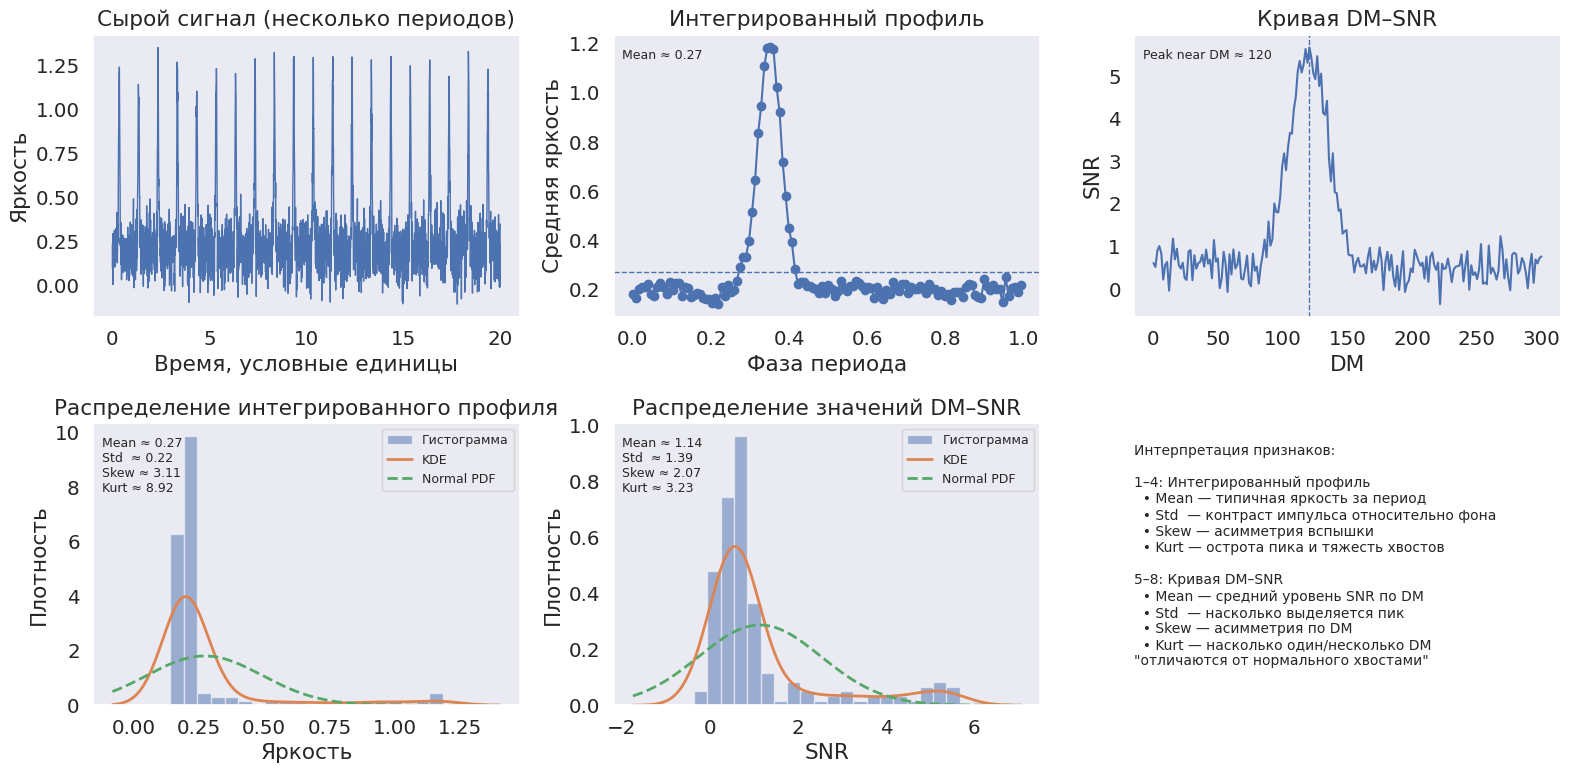
    
    
    

</details>

Укажите, какой датасет выберите:

diabetes_binary_5050split_health_indicators_BRFSS2015.csv

Скачайте файл и прочитайте его с помощью `pandas`.

In [5]:
dataset = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
dataset.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


Разделите выборку на обучающую и тестовую

In [6]:
train, test = train_test_split(dataset, random_state=42, train_size = 0.8)

**1.** Исследуйте данные на предмет количества объектов и признаков, типа признаков, наличия пропусков.

In [7]:
print("размер таблицы:", train.shape)
features = (train.columns).drop("Diabetes_binary")
for col in features:
  print(col, train[col].nunique())


размер таблицы: (56553, 22)
HighBP 2
HighChol 2
CholCheck 2
BMI 76
Smoker 2
Stroke 2
HeartDiseaseorAttack 2
PhysActivity 2
Fruits 2
Veggies 2
HvyAlcoholConsump 2
AnyHealthcare 2
NoDocbcCost 2
GenHlth 5
MentHlth 31
PhysHlth 31
DiffWalk 2
Sex 2
Age 13
Education 6
Income 8


Выполните необходимую обработку признаков. Используйте для этого конструкции `ColumnTransformer`, `Pipeline` и подобные.

In [8]:
target = "Diabetes_binary"
num_features = ["BMI", "MentHlth", "PhysHlth", "Age", "GenHlth"]
cat_features = features.drop(num_features)

Y_train = train[target]
X_train = train.drop(columns = target)

Y_test = test[target]
X_test = test.drop(columns = target)

preprocessor = ColumnTransformer(
    [
        (
            "num",
            StandardScaler(),
            num_features,
        ),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False),
            cat_features,
        ),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)



**2.** Обучите две модели логистической регрессии с помощью методов
* простой градиентный спуск;
* стохастический градиентный спуск.

In [9]:
model_gd = MyLogisticRegression(method = "gd", learning_rate = 0.01, tol = 1e-6, max_iter = 1000)
model_sgd = MyLogisticRegression(method = "sgd", learning_rate = 0.01, batch_size=4000, tol = 1e-6, max_iter = 1000)

model_gd.fit(X_train_processed, Y_train)
model_sgd.fit(X_train_processed, Y_train)

y_pred = model_gd.predict(X_test_processed)
acc = accuracy_score(Y_test, y_pred)
print(f"Accuracy gd: {acc:.4f}")

y_pred = model_sgd.predict(X_test_processed)
acc = accuracy_score(Y_test, y_pred)
print(f"Accuracy sgd: {acc:.4f}")


Accuracy gd: 0.7365
Accuracy sgd: 0.7364


Постройте график, на котором нанесите две кривые обучения, каждая из которых отображает зависимость оптимизируемого функционала от номера итерации метода. Нарисуйте также график зависимости этого функционала от времени работы метода. 

*Замечания:*
* Все графики должны быть информативны, с подписанными осями и т.д..
* Для чистоты эксперимента желательно не запускать в момент обучения другие задачи.

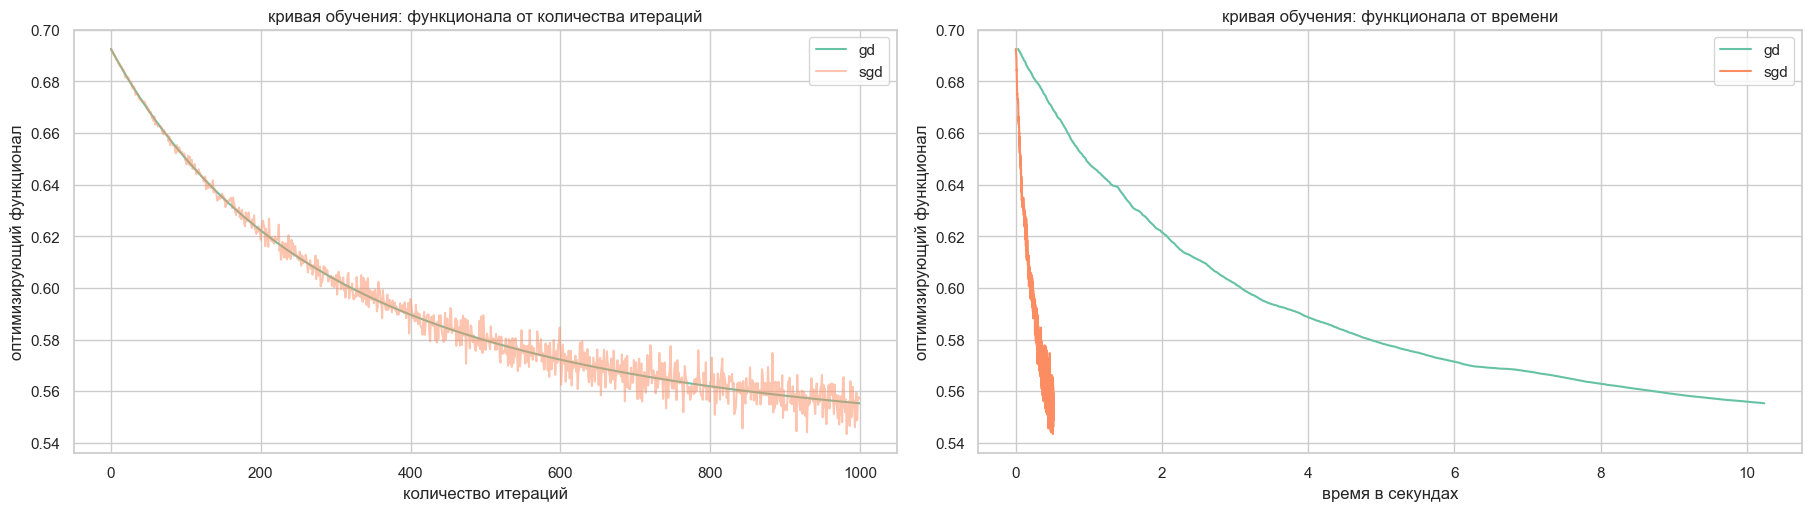

In [11]:
loss_gd = [i["loss"] for i in model_gd.history]
loss_sgd = [i["loss"] for i in model_sgd.history]


times_gd = [i["time"] for i in model_gd.history]
times_sgd = [i["time"] for i in model_sgd.history]

fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
axes[0].plot(loss_gd, label = "gd")
axes[0].plot(loss_sgd, alpha = 0.5, label = "sgd")
axes[0].set_xlabel("количество итераций")
axes[0].set_ylabel("оптимизирующий функционал")
axes[0].set_title("кривая обучения: функционала от количества итераций")
axes[0].legend();

axes[1].plot(times_gd, loss_gd, label = "gd")
axes[1].plot(times_sgd, loss_sgd, label = "sgd")
axes[1].set_xlabel("время в секундах")
axes[1].set_ylabel("оптимизирующий функционал")
axes[1].set_title("кривая обучения: функционала от времени")
axes[1].legend();

Сделайте выводы. Что будет при обучении на датасете, если  увеличить количество объектов, а число признаков оставить прежним?

На графиках видно что GD убывает плавно и почти монотонно с замедленнеим, тоже самое можно сказать про SGD но у него есть разброс из-за случайного выбора бачей.

Если увеличить количесвто обьектов, то точность для GD увелисться, но оно будет медленее работать, так как времч работы линенйо зависит от количесвта обьектов, в то время как для SGD тоже вырастет точность но время работы почти не изменится, так как рамзер батчей останется постоянным

**3.** Исследуйте влияние размер шага (`learning_rate`) на качество модели для двух режимов обучения (простой и стохастический градиентный спуск). Для каждого размера шага получите качество модели при использовании простого и стохастического градиентного спуска. Сравните качество полученных моделей по метрике `accuracy`.

<font color="green" size="5"><b>Исправления ниже</b></font>

/var/folders/g0/kzkhxj_52wd1b0trslf_kmd80000gn/T/ipykernel_6455/4087196189.py:41: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))
/var/folders/g0/kzkhxj_52wd1b0trslf_kmd80000gn/T/ipykernel_6455/4087196189.py:41: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


,lr,acc_gd,acc_sgd
0,0.000010,0.733432,0.730815
1,0.000139,0.735342,0.734352
2,0.001931,0.732654,0.732584
3,0.026827,0.740434,0.740576
4,0.372759,0.745102,0.744395
5,5.179475,0.654572,0.651460
6,71.968567,0.645237,0.647924
7,1000.000000,0.633779,0.673739


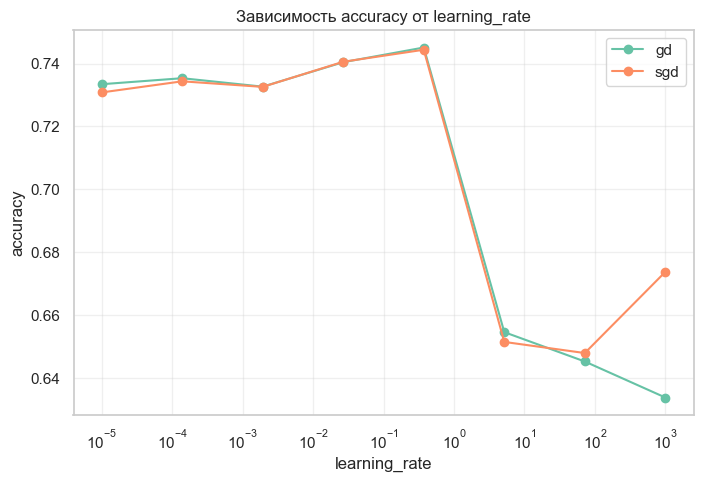

In [12]:
learning_rate_list = np.logspace(-5, 3, 8)
rows =[]
for lr in learning_rate_list:
    model_gd = MyLogisticRegression(method="gd", learning_rate=lr, tol=1e-6, max_iter=1000)
    model_sgd = MyLogisticRegression(method="sgd", learning_rate=lr, batch_size=4000, tol=1e-6, max_iter=1000)

    model_gd.fit(X_train_processed, Y_train)
    model_sgd.fit(X_train_processed, Y_train)

    acc_gd = accuracy_score(Y_test, model_gd.predict(X_test_processed))
    acc_sgd = accuracy_score(Y_test, model_sgd.predict(X_test_processed))

    rows.append({"lr": lr, "acc_gd": acc_gd, "acc_sgd": acc_sgd})

df_lr = pd.DataFrame(rows)
display(df_lr)

plt.figure(figsize=(8, 5))
plt.plot(df_lr["lr"], df_lr["acc_gd"], marker="o", label="gd")
plt.plot(df_lr["lr"], df_lr["acc_sgd"], marker="o", label="sgd")
plt.xscale("log")
plt.xlabel("learning_rate")
plt.ylabel("accuracy")
plt.title("Зависимость accuracy от learning_rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<font color="green" size="5"><b>Исправления выше</b></font>

Сделайте выводы

самая лучшая точность достигается при learning_rate $\approx 0.5$

Постройте кривые обучения для различных `learning_rate`. Не обязательно рассматривать все `learning_rate`, так как их слишком много, и график будет нагроможден. Возьмите около половины из них.

<font color="green" size="5"><b>Исправления ниже</b></font>

,lr,iter_gd,time_gd,iter_sgd,time_sgd
0,0.000010,1,0.036330,1,0.001335
1,0.001931,1000,8.894244,61,0.051371
2,0.372759,1000,9.138145,1000,0.509955
3,71.968567,1000,9.858787,1000,0.494087


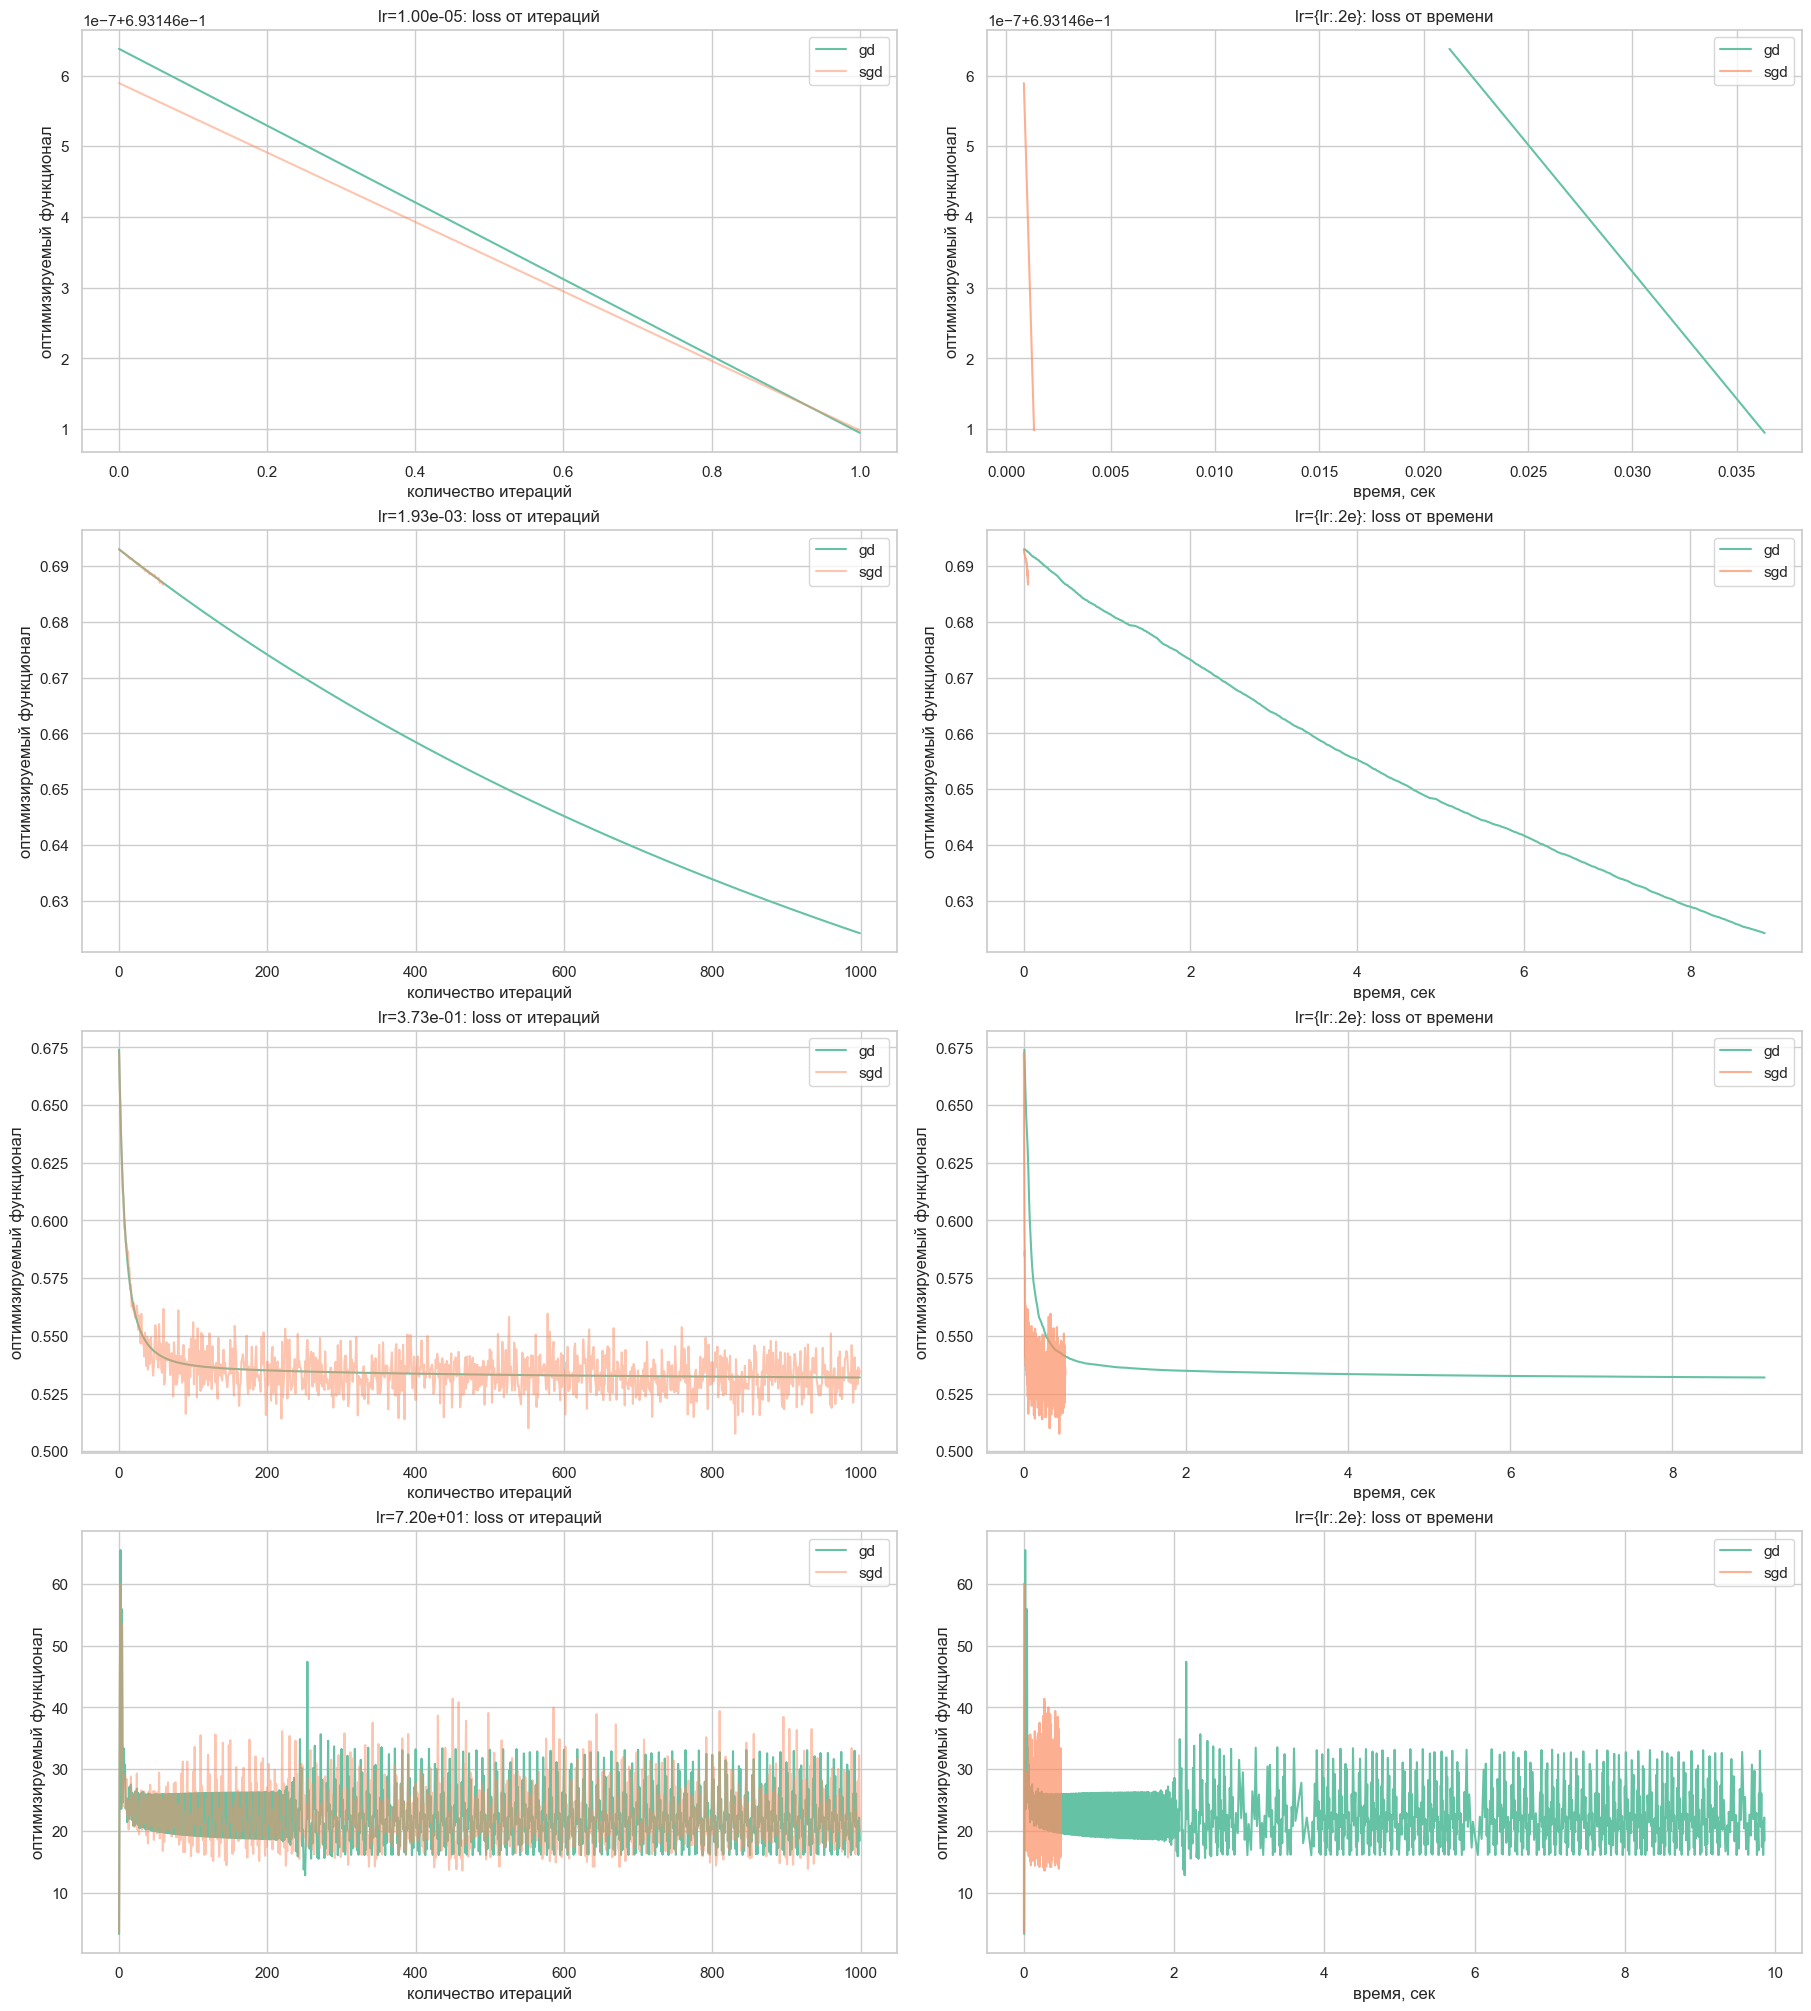

In [13]:
rows_conv = []
fig, axes = plt.subplots(4, 2, figsize=(18, 20), constrained_layout=True)

for row, j in enumerate(range(0, 8, 2)):  # j = 0,2,4,6
    lr = learning_rate_list[j]

    model_gd = MyLogisticRegression(method="gd", learning_rate=lr, tol=1e-6, max_iter=1000)
    model_sgd = MyLogisticRegression(method="sgd", learning_rate=lr, batch_size=4000, tol=1e-6, max_iter=1000)

    model_gd.fit(X_train_processed, Y_train)
    model_sgd.fit(X_train_processed, Y_train)

    loss_gd = [h["loss"] for h in model_gd.history]
    loss_sgd = [h["loss"] for h in model_sgd.history]
    times_gd = [h["time"] for h in model_gd.history]
    times_sgd = [h["time"] for h in model_sgd.history]

    axes[row, 0].plot(loss_gd, label="gd")
    axes[row, 0].plot(loss_sgd, alpha=0.5, label="sgd")
    axes[row, 0].set_xlabel("количество итераций")
    axes[row, 0].set_ylabel("оптимизируемый функционал")
    axes[row, 0].set_title(f"lr={lr:.2e}: loss от итераций")
    axes[row, 0].legend()

    axes[row, 1].plot(times_gd, loss_gd, label="gd")
    axes[row, 1].plot(times_sgd, loss_sgd, alpha=0.7,label="sgd")
    axes[row, 1].set_xlabel("время, сек")
    axes[row, 1].set_ylabel("оптимизируемый функционал")
    axes[row, 1].set_title("lr={lr:.2e}: loss от времени")
    axes[row, 1].legend()

    rows_conv.append({
    "lr": lr,
    "iter_gd": model_gd.n_iter_,
    "time_gd": model_gd.history[-1]["time"],
    "iter_sgd": model_sgd.n_iter_,
    "time_sgd": model_sgd.history[-1]["time"],
    })
pd.DataFrame(rows_conv)

<font color="green" size="5"><b>Исправления выше</b></font>

Какой `learning_rate` стоит выбирать в зависимости от способа обучения модели? Чем плохи маленькие и большие `learning_rate`?

Для GD нужно брать чуть больше  `learning_rate` так как шак и градиент точные и стаблильные. Для SGD нужно брать `learning_rate` чуть меньше, из-за шумов и случайности в спуске.
При маленьких `learning_rate` модель делает всего неколько итераций поэтому точность низкая, при больших `learning_rate` постоянно перескакиваем минимум тк погрешность меньше чем наш шаг 

**4.** Рассмотрите наилучшую модель с предыдущего шага. Визуализируйте значения полученных оценок коэффициентов.

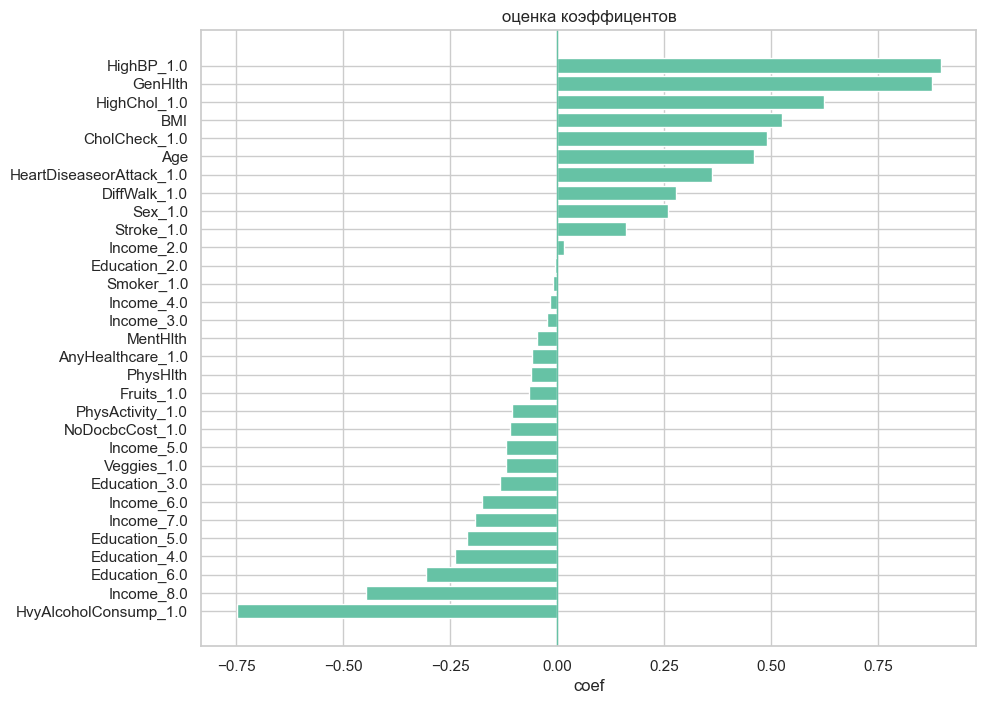

In [648]:
model_best = MyLogisticRegression(method = "sgd", learning_rate = learning_rate_list[4], batch_size = 4000, tol = 1e-6, max_iter = 1000)

model_best.fit(X_train_processed, Y_train)

num_feature_names = np.array(num_features)
ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_features)
all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

# коэффициенты модели
coef = model_best.coef_

coef_df = pd.DataFrame({"feature": all_feature_names, "coef": coef})
coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

plot_df = coef_df.sort_values("coef")

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["coef"])
plt.axvline(0, linewidth=1)
plt.xlabel("coef")
plt.title("оценка коэффицентов")
plt.show()

Сравните данную модель с бейзлайном, который в качестве предсказания выдает самый частый класс на обучающей выборке.

In [649]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_processed, Y_train)

y_pred = dummy_model.predict(X_test_processed)

acc_base = accuracy_score(Y_test, y_pred)
print("accuracy baseline:", acc_base)

accuracy baseline: 0.49855010962585755


Насколько хорошее получилось качество обученной модели?

Бейзлайн модель сильно проигрывает по точности нашей модели, в силу большого количества параметров

**5.** Исследуйте логит на линейность по некоторым из признаков.

In [650]:
def kernel_smooth_logit(
    x: np.ndarray, y: np.ndarray, x_grid: np.ndarray, h: float = 1.0, epsilon: float = 1e-10
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Вычисляет сглаженный логит с помощью ядерного сглаживания.

    Параметры:
    x : np.ndarray, shape (n_samples,)
        Значения признака для вычисления сглаживания.
    y : np.ndarray, shape (n_samples,)
        Целевые переменные (должны содержать 0 и 1).
    x_grid : np.ndarray, shape (n_points,)
        Сетка точек, в которых вычисляется оценка логита.
    h : float, default=1.0
        Ширина ядра (bandwidth) для сглаживания.
    epsilon : float, default=1e-10
        Малое число для регуляризации и избежания численной нестабильности.

    Возвращает:
    x_grid : np.ndarray
        Исходная сетка точек (возвращается для удобства).
    logit_smoothed : np.ndarray
        Сглаженные значения логита в точках сетки.
    """
    # Гауссовское ядро
    kernel = sps.norm(scale=h)

    # Вычисляем значения ядра
    kernel_values = kernel.pdf(x[:, np.newaxis] - x_grid[np.newaxis, :])

    # Ядерная оценка вероятности P(y=1|x)
    numerator = (y[:, np.newaxis] * kernel_values).sum(axis=0)
    denominator = kernel_values.sum(axis=0)

    # Избегаем деления на ноль
    denominator = np.maximum(denominator, epsilon)
    y_est = numerator / denominator

    # Регуляризация для избежания крайних значений
    y_est = np.clip(y_est, epsilon, 1 - epsilon)

    # Преобразование в логит: log(P/(1-P))
    logit_smoothed = np.log(y_est / (1 - y_est))

    return x_grid, logit_smoothed


def plot_logit_linearity_check(
    X: np.ndarray,
    y: Union[np.ndarray, list],
    h: float = 1.0,
    feature_names: list = None,
    size: Optional[int] = 5000,
    use_percentiles: bool = True,
    figsize: Tuple[int, int] = (16, 4),
) -> None:
    """
    Визуальная проверка линейности логита для всех признаков.

    Параметры:
    X : np.ndarray, shape (n_samples, n_features)
        Матрица признаков данных.
    y : Union[np.ndarray, list], shape (n_samples,)
        Вектор меток классов (0 и 1).
    h : float, default=1.0
        Ширина ядра для сглаживания.
    size : Optional[int], default=5000
        Размер подвыборки для ускорения вычислений. Если None, используется вся выборка.
    use_percentiles : bool, default=True
        Если True, использует 5-й и 95-й процентили для построения сетки (устойчиво к выбросам).
        Если False, использует минимум и максимум.
    figsize : Tuple[int, int], default=(12, 4)
        Размер фигуры для отображения графиков.
    """
    y = np.asarray(y)

    n_features = len(feature_names)

    if size is None or size > len(X):
        size = len(X)

    plt.figure(figsize=figsize)

    for feature_idx in range(n_features):
        # Выбираем подвыборку для ускорения
        x_subset = X[:size, feature_idx]
        y_subset = y[:size]

        # Сетка точек
        if use_percentiles:
            x_min = np.percentile(x_subset, 5)
            x_max = np.percentile(x_subset, 95)
        else:
            x_min = x_subset.min()
            x_max = x_subset.max()

        x_grid = np.linspace(x_min, x_max, 100)

        # Вычисляем сглаженный логит
        _, logit_smoothed = kernel_smooth_logit(x_subset, y_subset, x_grid, h)

        # Строим график
        plt.subplot(1, n_features, feature_idx + 1)
        plt.plot(x_grid, logit_smoothed, lw=3)
        plt.xlabel(feature_names[feature_idx])
        plt.ylabel("Приближение логита", fontsize=16)

    plt.suptitle("Проверка линейности логита")
    plt.tight_layout()
    plt.show()

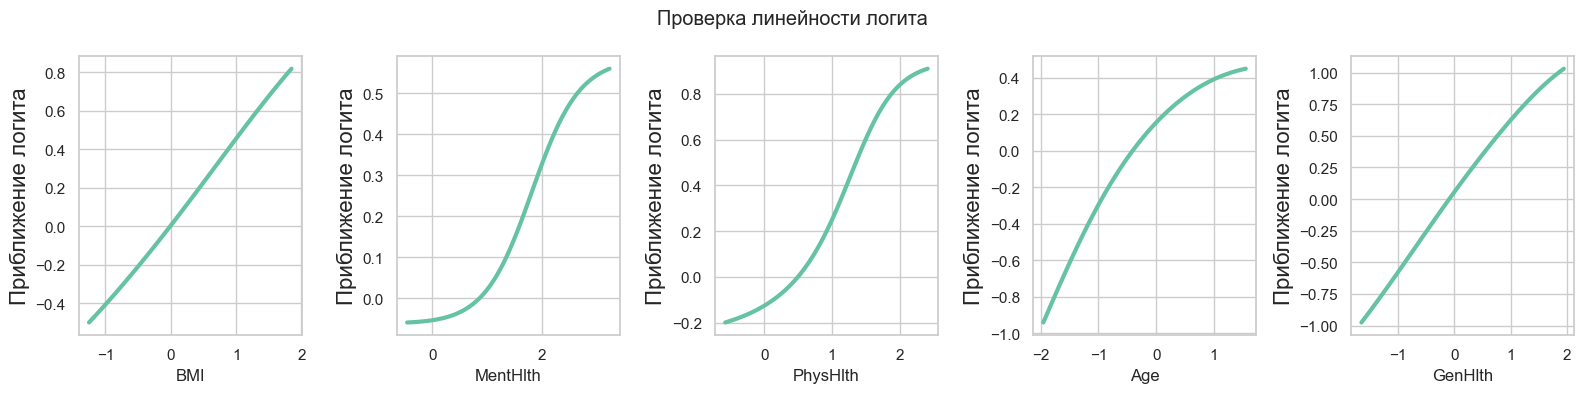

In [651]:
h = 0.8  # ширина ядра
size = 50000  # проверим линейность на небольшой подвыборке
X_num = X_train_processed[:, :len(num_features)]
plot_logit_linearity_check(X_num, Y_train, h=h, feature_names=num_features, size=size)

Есть ли какая-то нелинейность по каким-либо признакам? Если да, попробуйте улучшить модель, рассмотрев преобразования признаков. Сравните полученную модель по качеству с предыдущими.

Достаточно простого решения, тратить много времени на подобный анализ признаков в данном случае не нужно.

In [658]:
# добавим MentHlth^2, PhysHlth^2, Age^2

X_train_new = X_train.copy()
X_test_new = X_test.copy()

X_train_new["MentHlth_sq"] = X_train_new["MentHlth"] ** 2
X_test_new["MentHlth_sq"] = X_test_new["MentHlth"] ** 2

X_train_new["PhysHlth_sq"] = X_train_new["PhysHlth"] ** 2
X_test_new["PhysHlth_sq"] = X_test_new["PhysHlth"] ** 2

X_train_new["Age_sq"] = X_train_new["Age"] ** 2
X_test_new["Age_sq"] = X_test_new["Age"] ** 2

num_features_new = num_features + ["MentHlth_sq", "PhysHlth_sq", "Age_sq"]
cat_features_new = X_train_new.columns.drop(num_features_new)

preprocessor_new = ColumnTransformer(
    [
        ("num", StandardScaler(), num_features_new),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features_new),
    ]
)

X_train_processed_new = preprocessor_new.fit_transform(X_train_new)
X_test_processed_new = preprocessor_new.transform(X_test_new)

In [659]:
model_new = MyLogisticRegression(
    method="sgd",
    learning_rate=learning_rate_list[4],
    batch_size=4000,
    tol=1e-6,
    max_iter=1000,
)

model_new.fit(X_train_processed_new, Y_train)

MyLogisticRegression(batch_size=4000,
                     learning_rate=np.float64(0.3727593720314938),
                     max_iter=1000, method='sgd', tol=1e-06)

In [660]:
y_pred_old = model_best.predict(X_test_processed)
acc_old = accuracy_score(Y_test, y_pred_old)

y_pred_new = model_new.predict(X_test_processed_new)
acc_new = accuracy_score(Y_test, y_pred_new)

print("old accuracy:", acc_old)
print("new accuracy:", acc_new)

old accuracy: 0.7455972841077869
new accuracy: 0.7444656623523587


По графику видно, что некоторые признаки заметно увеличивают вероятность диабета. Например, наличие высокого давления (HighBP) увеличивает шанс диабета примерно в 1.6 раза, а плохое общее состояние здоровья (GenHlth) и высокий холестерин (HighChol) тоже существенно повышают вероятность заболевания.

Также видно, что физическая активность, употребление овощей и фруктов связаны со снижением вероятности диабета (odds ratio меньше 1). В целом такие результаты выглядят логичными и согласуются с интуитивными представлениями о факторах риска диабета.

In [672]:
# модель без стандратизации
preprocessor_no_scale = ColumnTransformer(
    [
        ("num", "passthrough", num_features),  # числовые без стандартизации
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
    ]
)

X_train_processed_ns = preprocessor_no_scale.fit_transform(X_train)
X_test_processed_ns = preprocessor_no_scale.transform(X_test)

model_no_scale = MyLogisticRegression(
    method="gd",
    learning_rate = 0.01,
    tol=1e-6,
    max_iter=1000,
)

model_no_scale.fit(X_train_processed_ns, Y_train)

y_pred_ns = model_no_scale.predict(X_test_processed_ns)
acc_ns = accuracy_score(Y_test, y_pred_ns)

print("acc_ns accuracy:", acc_ns)

acc_ns accuracy: 0.582290119527548


In [673]:
# имена признаков после препроцессинга
num_feature_names = np.array(num_features)

ohe = preprocessor_no_scale.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_features)

all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

# коэффициенты модели
coef = model_no_scale.coef_
odds = np.exp(coef)

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coef": coef,
    "odds_ratio": odds
}).sort_values("coef", ascending=False)

coef_df

,feature,coef,odds_ratio
5,HighBP_1.0,0.480540,1.616947
4,GenHlth,0.348177,1.416483
6,HighChol_1.0,0.326126,1.385591
17,DiffWalk_1.0,0.219221,1.245107
10,HeartDiseaseorAttack_1.0,0.180191,1.197446
9,Stroke_1.0,0.060828,1.062717
24,Income_2.0,0.036722,1.037404
25,Income_3.0,0.029953,1.030406
20,Education_3.0,0.024897,1.025210
3,Age,0.024199,1.024494


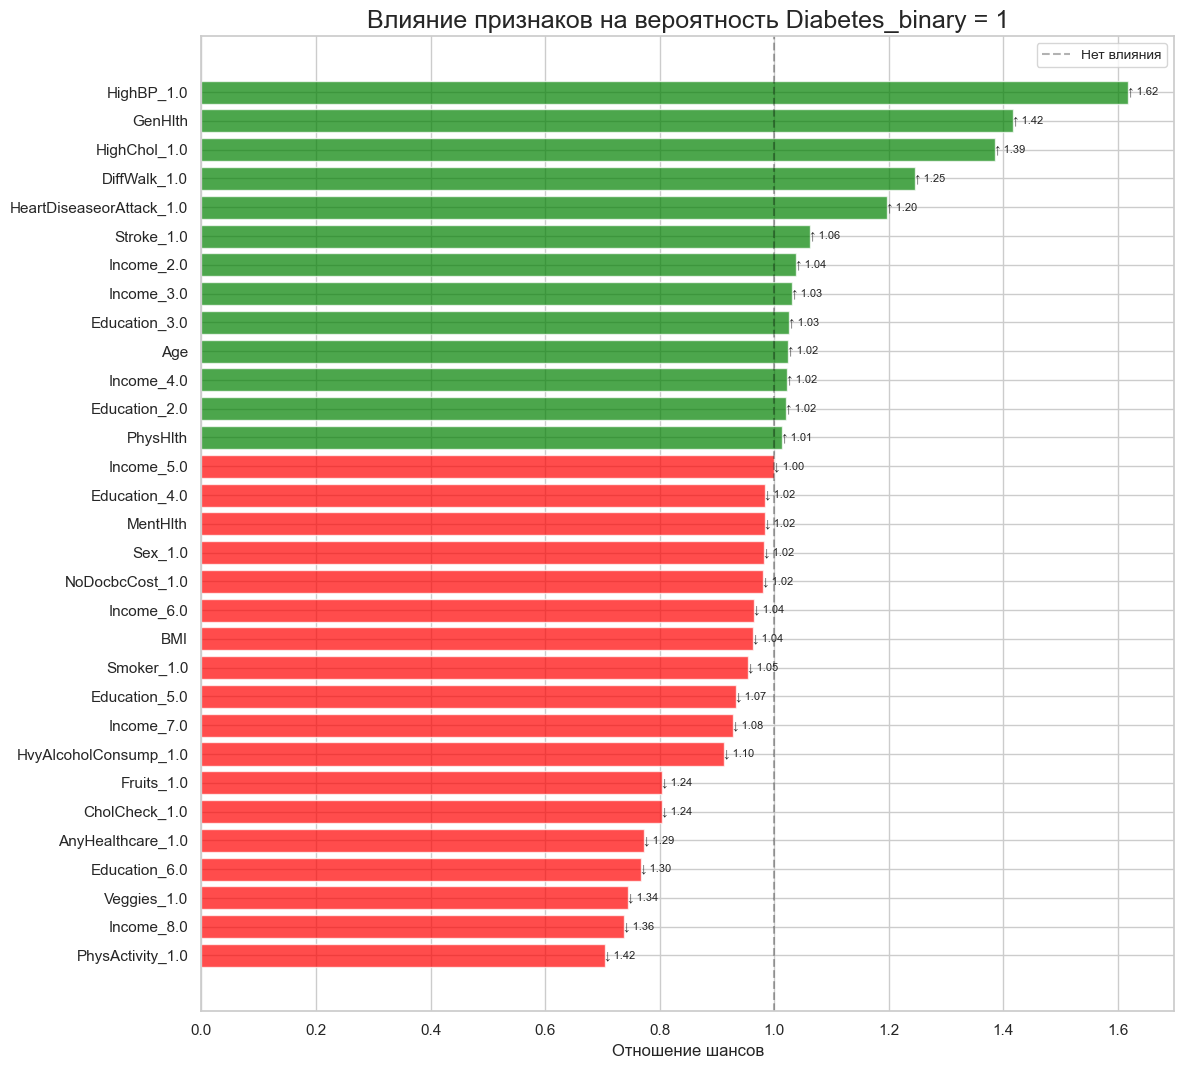

In [675]:
coef_plot_df = pd.DataFrame(
    {
        "Признак": all_feature_names,
        "Коэффициент": coef,
        "Отношение_шансов": odds,
    }
).sort_values("Отношение_шансов", ascending=True)

with sns.axes_style("white"):
    plt.figure(figsize=(12, max(8, 0.35 * len(coef_plot_df))))

colors = ["green" if x > 1 else "red" for x in coef_plot_df["Отношение_шансов"]]
plt.barh(coef_plot_df["Признак"], coef_plot_df["Отношение_шансов"], color=colors, alpha=0.7)

plt.xlabel("Отношение шансов")
plt.title("Влияние признаков на вероятность Diabetes_binary = 1", fontsize=18)
plt.axvline(x=1, color="black", linestyle="--", alpha=0.3, label="Нет влияния")

for ind, ratio in enumerate(coef_plot_df["Отношение_шансов"]):
    if ratio > 1:
        text = f"↑ {ratio:.2f}"
    else:
        text = f"↓ {1 / ratio:.2f}"
    plt.text(ratio, ind, text, va="center", ha="left", fontsize=8)

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

**7.** Какие больше всего влияют на изменение вероятности класса 1? Согласуются ли эти выводы с вашими личными представлениями о природе данных?

Ответ на этот вопрос не следует из предыдущего, поскольку там мы рассматривали коэффициенты как величины, имеющие различные единицы измерения. Чтобы сравнить коэффициенты, нам потребуется стандартизировать признаки, тем самым обезразмерить их и соответствующие коэффициенты. 

<details>
<summary> ➡️ Если ранее обучили модель без стандартизации признаков </summary>    
    Стандартизацию можно сделать с помощью <code>StandardScaler()</code> и обучить модель логистической регрессии заново. Но можно этого и не делать, немного поправив коэффициенты обученной ранее модели (получатся те же коэффициенты после стандартизации). Подумайте, как именно.
</details>

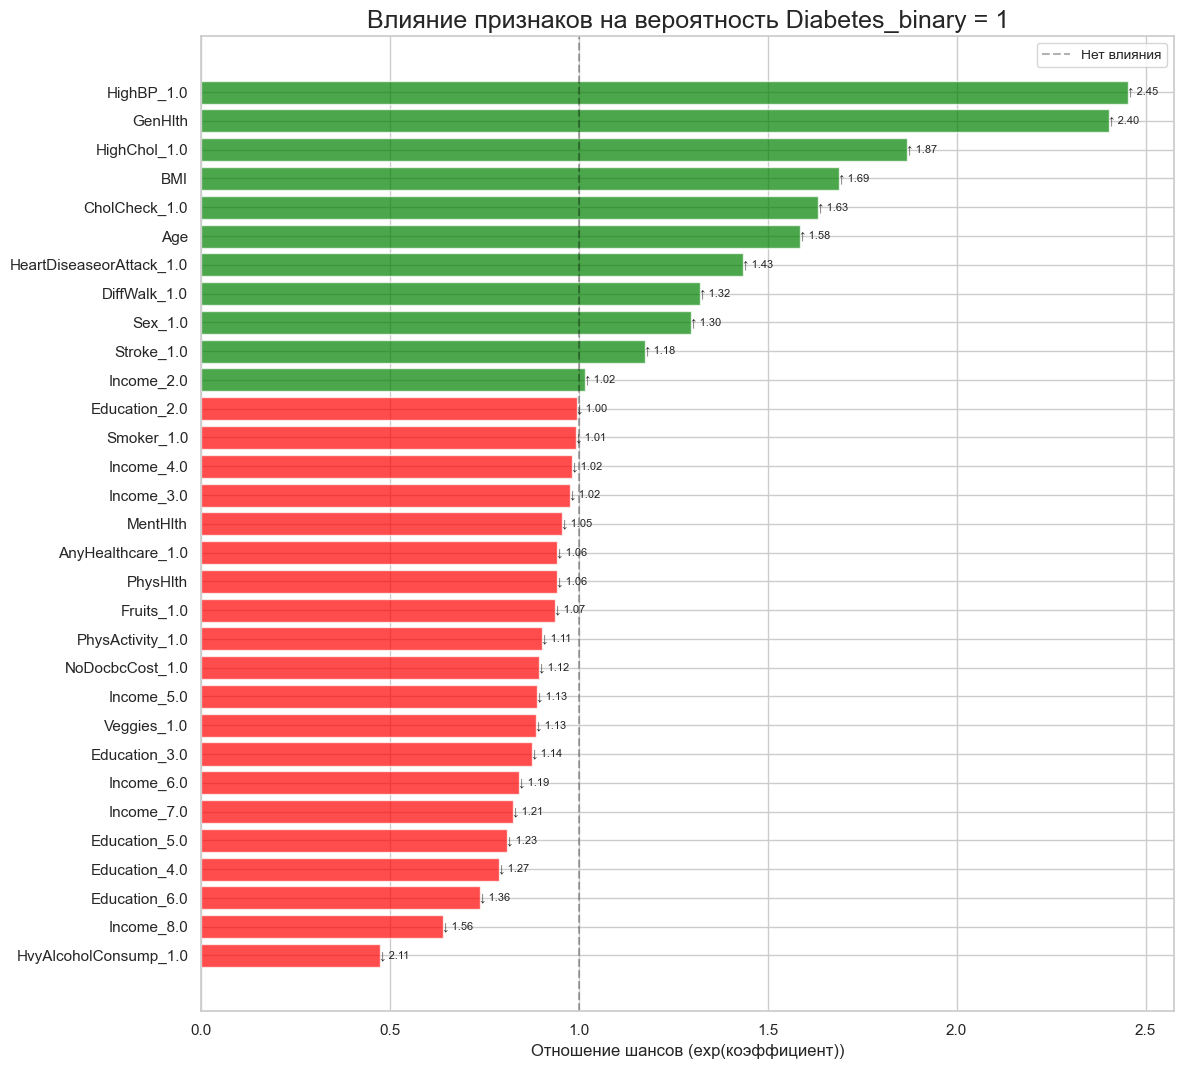

In [676]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# имена признаков после препроцессинга
num_feature_names = np.array(num_features)
ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_features)
all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

# коэффициенты модели
coef = model_best.coef_
odds = np.exp(coef)

coef_plot_df = pd.DataFrame(
    {
        "Признак": all_feature_names,
        "Коэффициент": coef,
        "Отношение_шансов": odds,
    }
).sort_values("Отношение_шансов", ascending=True)

with sns.axes_style("white"):
    plt.figure(figsize=(12, max(8, 0.35 * len(coef_plot_df))))

colors = ["green" if x > 1 else "red" for x in coef_plot_df["Отношение_шансов"]]
plt.barh(coef_plot_df["Признак"], coef_plot_df["Отношение_шансов"], color=colors, alpha=0.7)

plt.xlabel("Отношение шансов (exp(коэффициент))")
plt.title("Влияние признаков на вероятность Diabetes_binary = 1", fontsize=18)
plt.axvline(x=1, color="black", linestyle="--", alpha=0.3, label="Нет влияния")

for ind, ratio in enumerate(coef_plot_df["Отношение_шансов"]):
    if ratio > 1:
        text = f"↑ {ratio:.2f}"
    else:
        text = f"↓ {1 / ratio:.2f}"
    plt.text(ratio, ind, text, va="center", ha="left", fontsize=8)

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Для стандартизиорванных признаков самое сильное положительное влияние оказывают высокое давление (HighBP), общее состояние здоровья (GenHlth), высокий холестерин (HighChol), а также BMI и возраст. При этом такие признаки как например: физическая активность, употребление овощей и высокий уровень образования, наоборот связаны со снижением вероятности диабета.

**8. Вывод:**

все отлично...

*Надеемся, что ты все успел, и тебе понравилось! Ждем тебя на следующей лекции!*

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД